In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv('../data/raw/all_asins_daily.csv', parse_dates=['date'])
print(f"Total rows: {len(df):,}")
print(f"Total ASINs: {df['asin'].nunique()}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")

Total rows: 1,454,503
Total ASINs: 618
Date range: 2015-01-01 00:00:00 to 2026-05-31 00:00:00

Columns: ['date', 'amazon_price', 'asin', 'title', 'brand', 'category']

Data types:
date            datetime64[ns]
amazon_price           float64
asin                    object
title                   object
brand                   object
category                object
dtype: object


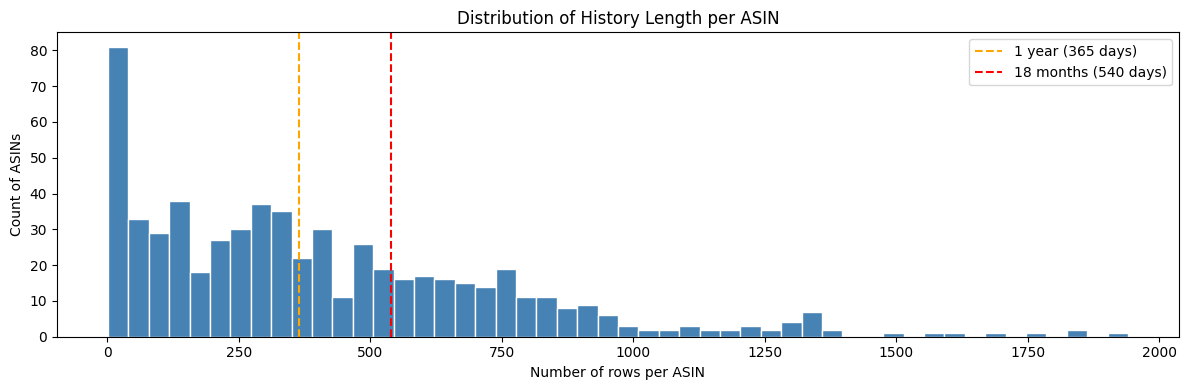


ASINs with 1 row (useless): 10
ASINs with <100 rows: 136
ASINs with 365+ rows (1 year): 282
ASINs with 540+ rows (18 months): 184
ASINs with 730+ rows (2 years): 106


In [3]:
history_counts = df.groupby('asin')['amazon_price'].count().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
plt.hist(history_counts, bins=50, color='steelblue', edgecolor='white')
plt.axvline(365, color='orange', linestyle='--', label='1 year (365 days)')
plt.axvline(540, color='red', linestyle='--', label='18 months (540 days)')
plt.xlabel('Number of rows per ASIN')
plt.ylabel('Count of ASINs')
plt.title('Distribution of History Length per ASIN')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nASINs with 1 row (useless): {(history_counts == 1).sum()}")
print(f"ASINs with <100 rows: {(history_counts < 100).sum()}")
print(f"ASINs with 365+ rows (1 year): {(history_counts >= 365).sum()}")
print(f"ASINs with 540+ rows (18 months): {(history_counts >= 540).sum()}")
print(f"ASINs with 730+ rows (2 years): {(history_counts >= 730).sum()}")

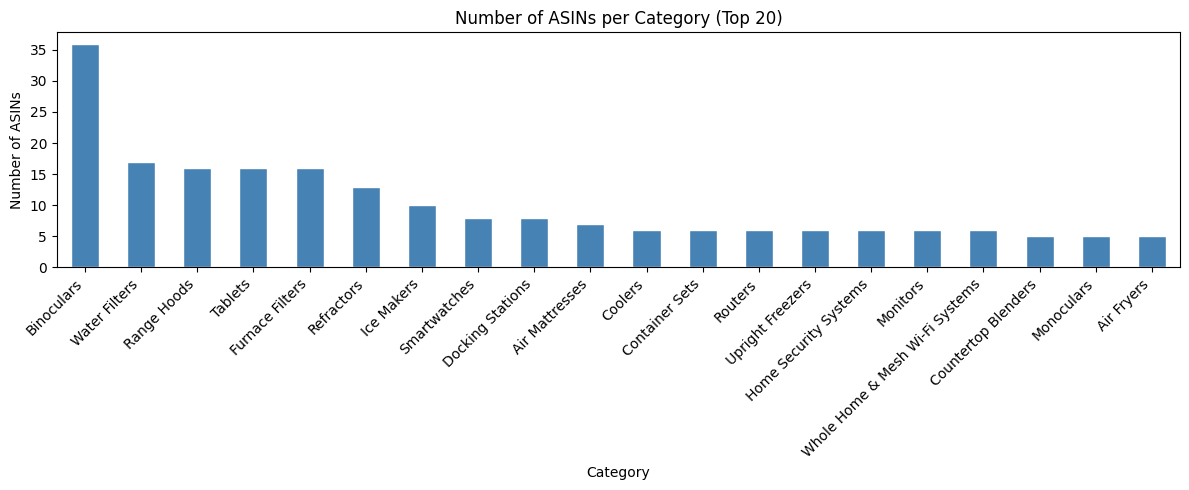

In [4]:
cat_dist = df.groupby('category')['asin'].nunique().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 5))
cat_dist.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of ASINs per Category (Top 20)')
plt.xlabel('Category')
plt.ylabel('Number of ASINs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

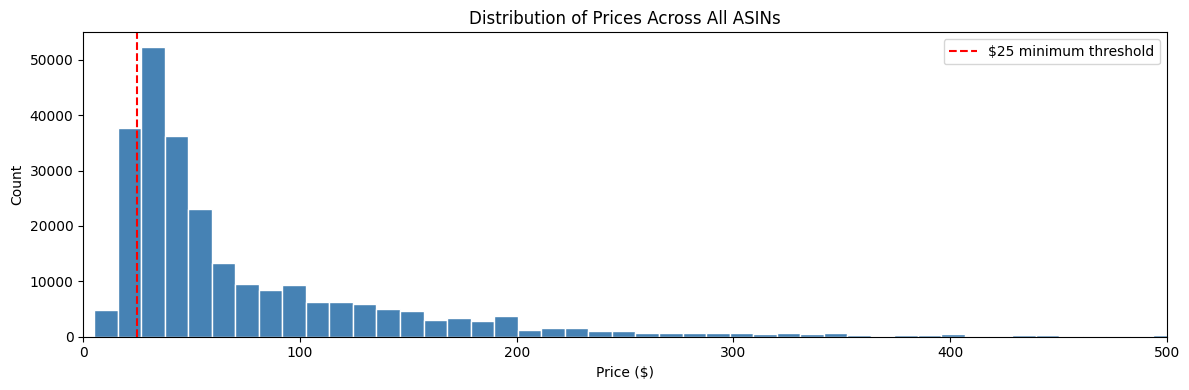

Price stats:
count   252356.00
mean        79.64
std         88.20
min          5.00
25%         29.99
50%         46.23
75%         98.76
max       1091.13
Name: amazon_price, dtype: float64


In [5]:
valid_prices = df['amazon_price'].dropna()
valid_prices = valid_prices[valid_prices > 0]

plt.figure(figsize=(12, 4))
plt.hist(valid_prices, bins=100, color='steelblue', edgecolor='white')
plt.axvline(25, color='red', linestyle='--', label='$25 minimum threshold')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.title('Distribution of Prices Across All ASINs')
plt.xlim(0, 500)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Price stats:\n{valid_prices.describe()}")

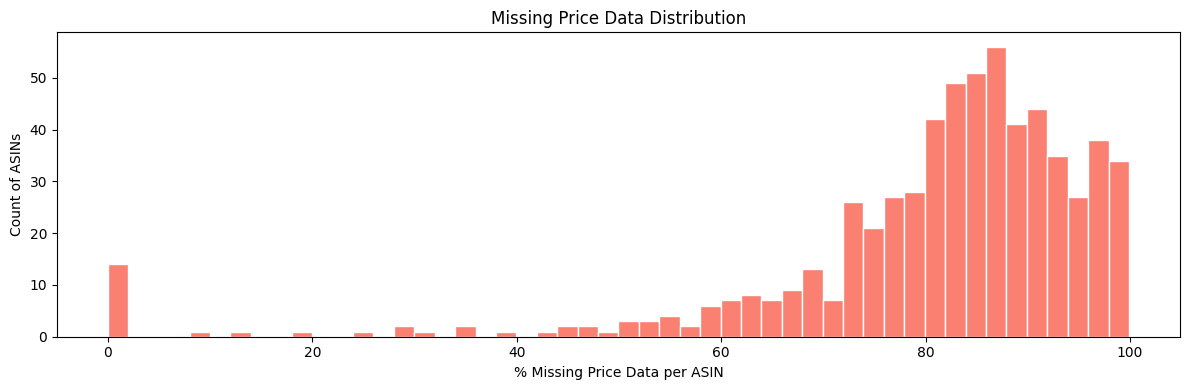

ASINs with >50% missing: 588
ASINs with >80% missing: 415
ASINs with <20% missing: 17


In [6]:
missing_by_asin = df.groupby('asin')['amazon_price'].apply(lambda x: x.isna().mean() * 100)

plt.figure(figsize=(12, 4))
plt.hist(missing_by_asin, bins=50, color='salmon', edgecolor='white')
plt.xlabel('% Missing Price Data per ASIN')
plt.ylabel('Count of ASINs')
plt.title('Missing Price Data Distribution')
plt.tight_layout()
plt.show()

print(f"ASINs with >50% missing: {(missing_by_asin > 50).sum()}")
print(f"ASINs with >80% missing: {(missing_by_asin > 80).sum()}")
print(f"ASINs with <20% missing: {(missing_by_asin < 20).sum()}")

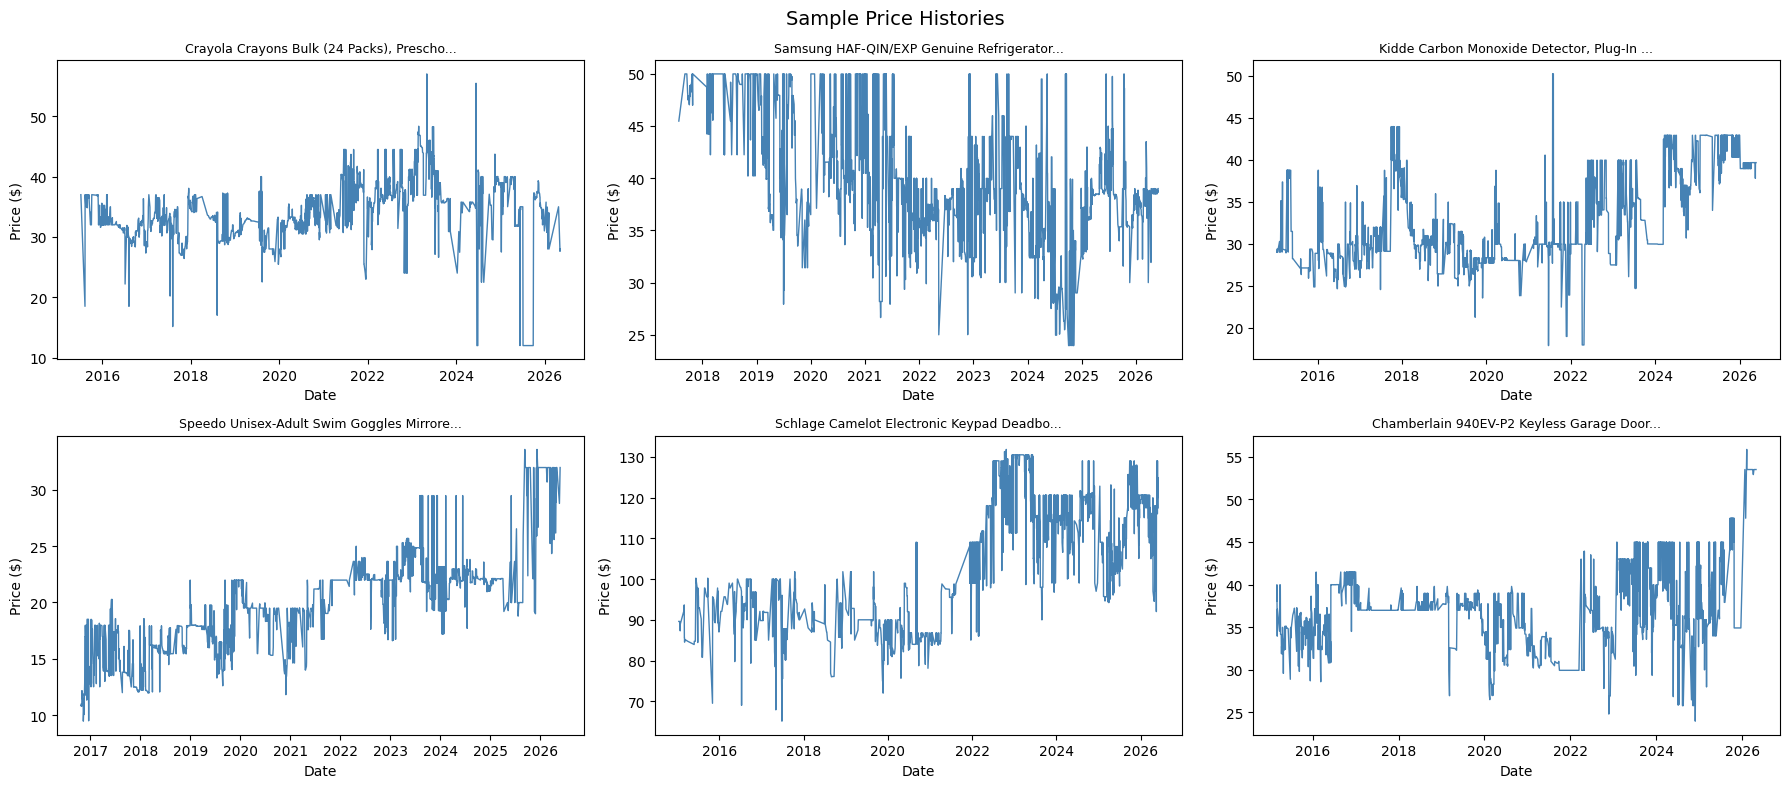

In [7]:
# Pick 6 ASINs with good history to visualize
good_asins = history_counts[history_counts >= 730].index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, asin in enumerate(good_asins):
    asin_df = df[df['asin'] == asin].set_index('date')['amazon_price'].dropna()
    title = df[df['asin'] == asin]['title'].iloc[0][:40]
    axes[i].plot(asin_df.index, asin_df.values, linewidth=1, color='steelblue')
    axes[i].set_title(f"{title}...", fontsize=9)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Price ($)')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Sample Price Histories', fontsize=14)
plt.tight_layout()
plt.show()